In [1]:
import cosima_cookbook as cc
from cosima_cookbook import distributed as ccd
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client(n_workers = 48)

In [3]:
	session = cc.database.create_session('/home/156/wf4500/databases/access/panan005_rerun.db') #panan005
	#session = cc.database.create_session() #panan01
	
	start_time='1999-01-01'     
	end_time='2001-12-31'
	#Start_time0 and end_time0 are for importing the daily transport, and it ahsthe number of days in the month    
	start_time0='1999-01-01'     
	end_time0='2001-12-31'
	print(start_time0) 
	print(end_time0) 
	exp = 'panan01_yr2000_HTsigma'
	
	print("Start date =" + start_time) 
	year2=str(int(start_time[0:4])+1)
	month2=str(int(start_time[5:7])+1)
	month2=str(int(month2))
	month2 = month2.zfill(2)    
	print("month2 is =" + month2) 
	print("year2 is =" + str(year2))     
	
	print("End date =" + end_time) 
	
	
	time_period = str(int(start_time[:4]))+'-'+str(int(end_time[:4]))
	
	# reference density value:
	rho_0 = 1035.0
	# specific heat capacity of sea water:
	cp = 3992.1
	lat_range = slice(-90,-59)
	
	isobath_depth = 1000
	
	# pick a freezing point temp:
	temp_freezing = -1.9
	

1999-01-01
2001-12-31
Start date =1999-01-01
month2 is =02
year2 is =2000
End date =2001-12-31


In [4]:
start_time0='2000-01-01'
end_time0='2000-12-31'
volcello = cc.querying.getvar('panant-005-zstar-ACCESSyr2','volcello',session,ncfile='%month_rho2.nc',\
                          start_time=start_time,end_time=end_time)\
.sel(time=slice(start_time,end_time))
temp = cc.querying.getvar('panant-005-zstar-ACCESSyr2','thetao',session,ncfile='%month_rho%',\
                          start_time=start_time,end_time=end_time)\
.sel(time=slice(start_time,end_time))
temp_masked = temp.where(volcello>1.5E-1) #Masking off temperature in non-existing density layers
#minimuns and maximuns
minT = temp_masked.min().compute(); maxT = temp_masked.max().compute()

In [5]:
print('Min temperature is ' + str(minT.values) + ' Celsius, ' +\
      'Max temperature is ' + str(maxT.values) + ' Celsius')

Min temperature is -328.7495 Celsius, Max temperature is 5831.399 Celsius


In [6]:
#sanity check on the masking
n = 2
volcello_t0masked = volcello.isel(time=n).where(volcello.isel(time=n)>1.5E-1)
volcello_t0masked.min().values
print('Min volcello is ' + str(volcello_t0masked.min().values) + ' m3 ')

Min volcello is 3.808407 m3 


In [7]:
temp_zonalmin = temp_masked.min('time').min('xh').compute()
temp_zonalmax = temp_masked.max('time').max('xh').compute()
#lets try it at a monthly mean output

temp_zonalmin_t0 = temp_masked.isel(time=n).min('xh').compute()
temp_zonalmax_t0 = temp_masked.isel(time=n).max('xh').compute()

(-80.0, -60.0)

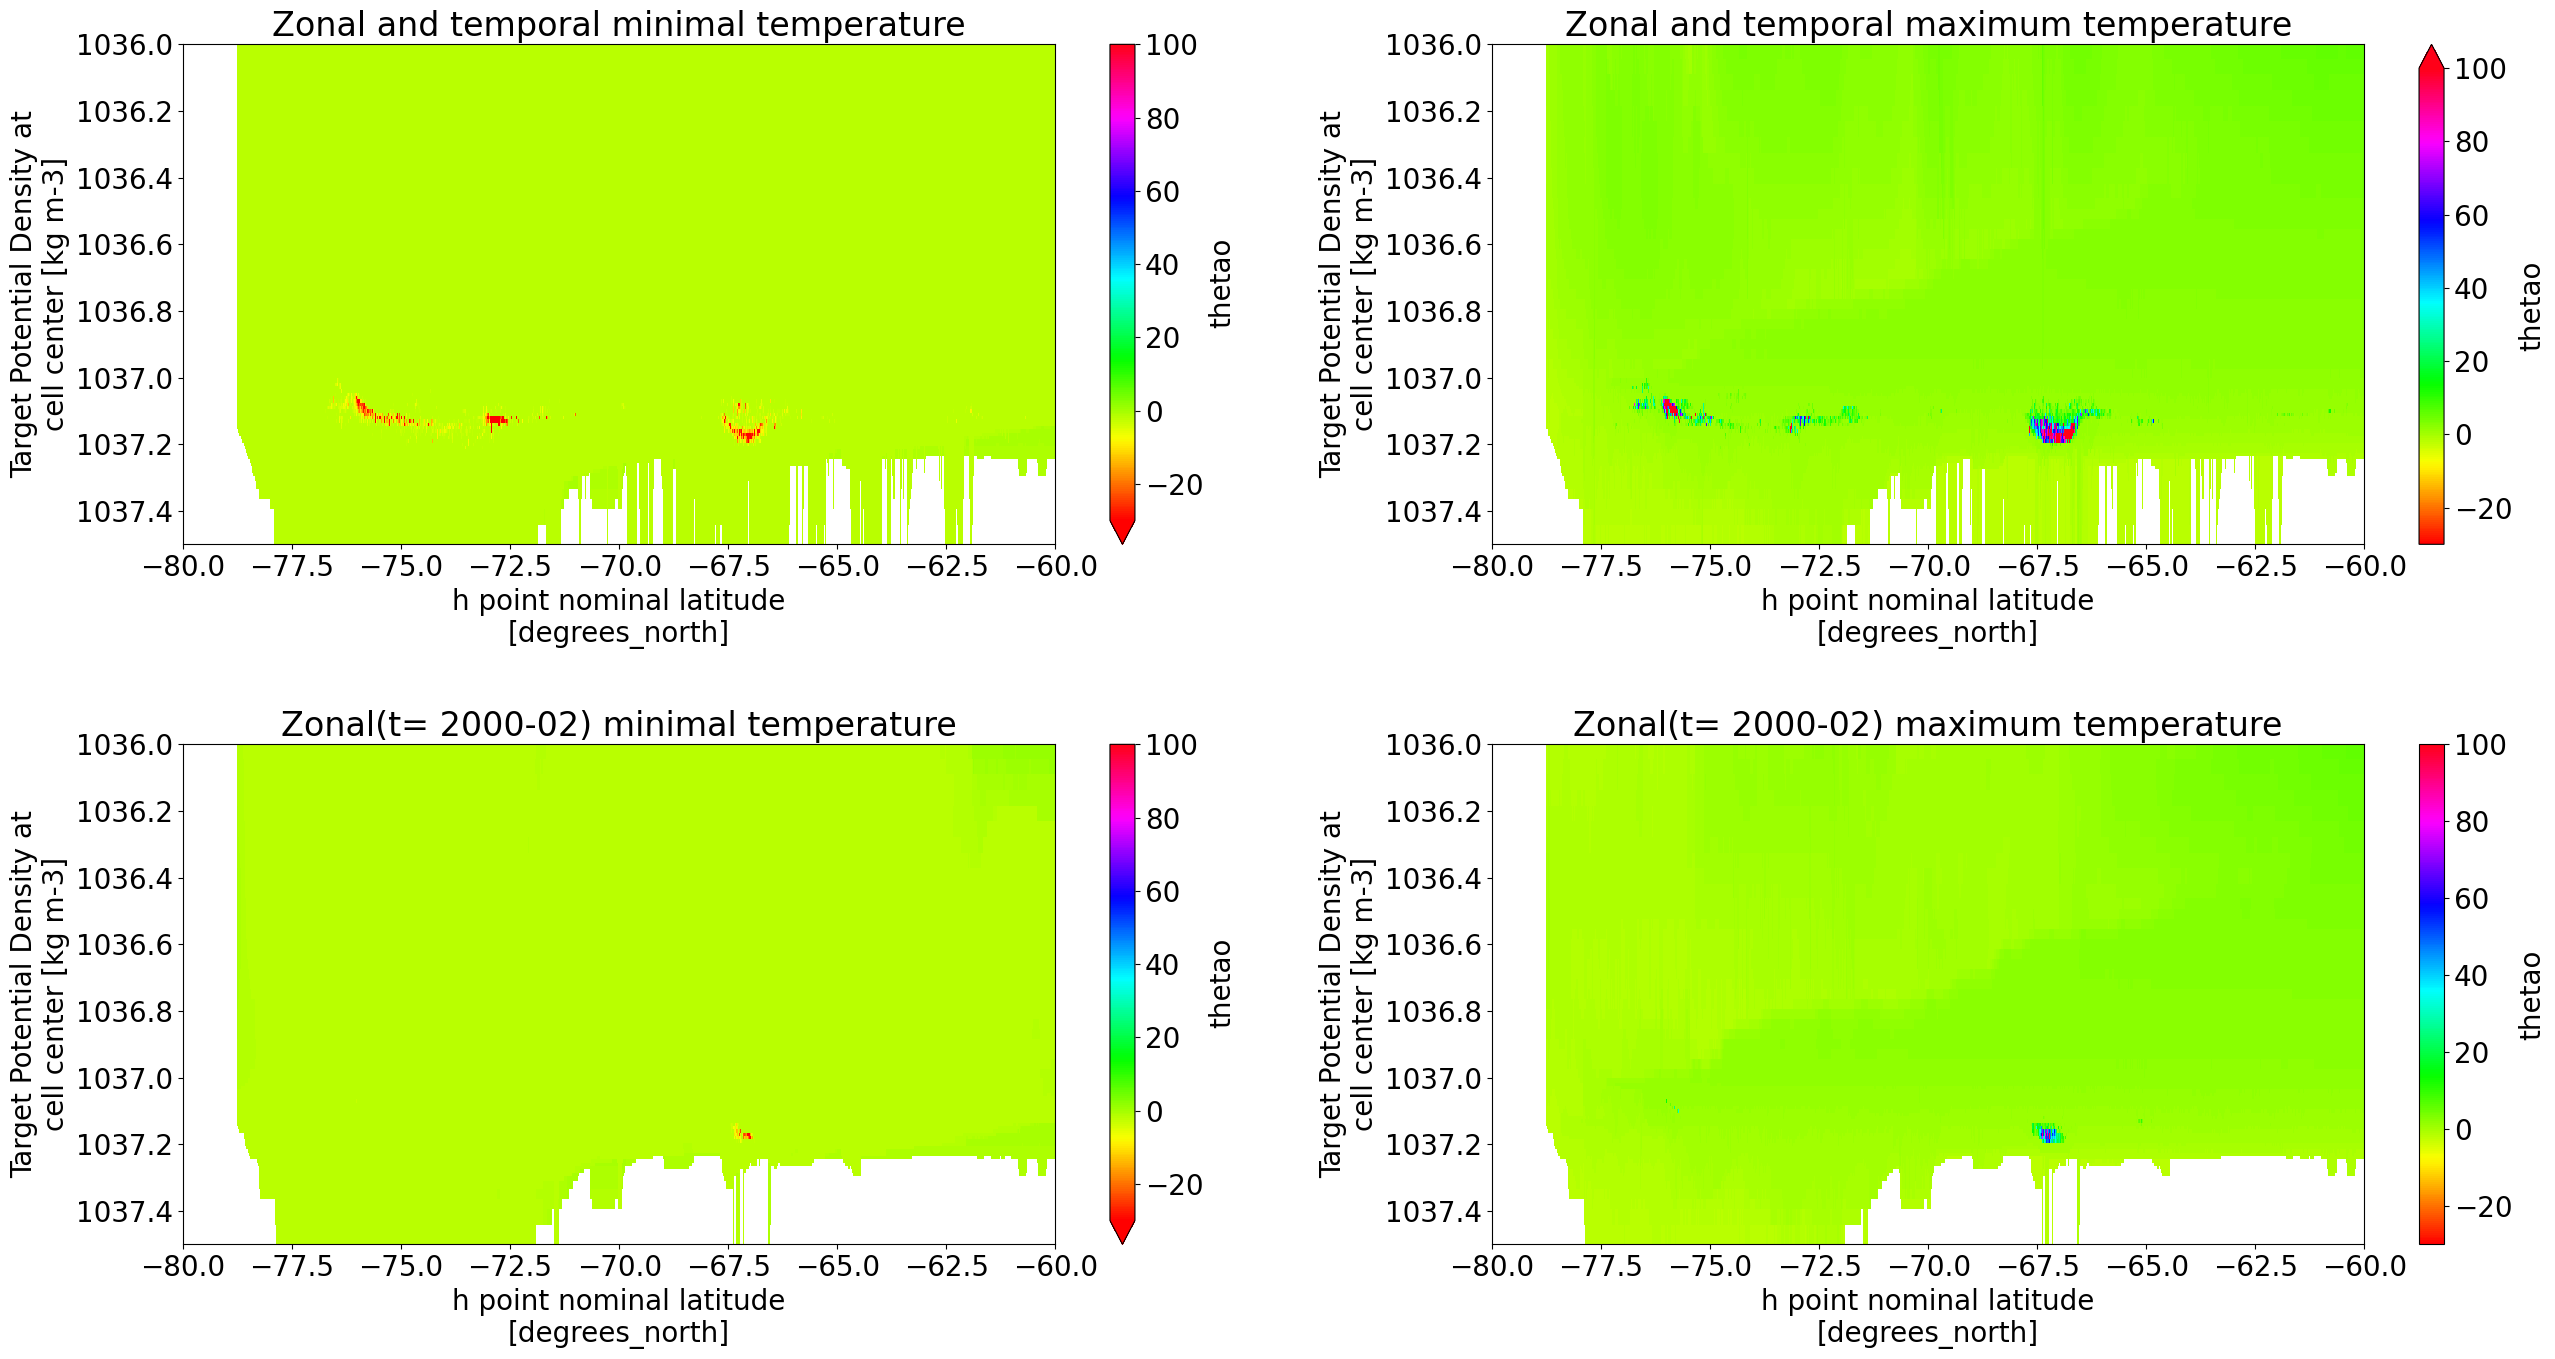

In [8]:
plt.figure(figsize=(30,15))
plt.subplots_adjust(left=0.1,bottom=0.1, right=0.9, top=0.9, wspace=0.2, hspace=0.4)
plt.rcParams.update({'font.size': 20})

plt.subplot(2,2,1)
temp_zonalmin.plot.pcolormesh(y='rho2_l',vmin=-30,vmax=100,cmap='hsv')
plt.title('Zonal and temporal minimal temperature')
plt.ylim(1037.5,1036)
plt.xlim(-80,-60)

plt.subplot(2,2,2)
temp_zonalmax.plot.pcolormesh(y='rho2_l',vmin=-30,vmax=100,cmap='hsv')
plt.title('Zonal and temporal maximum temperature')
plt.ylim(1037.5,1036)
plt.xlim(-80,-60)

plt.subplot(2,2,3)
temp_zonalmin_t0.plot.pcolormesh(y='rho2_l',vmin=-30,vmax=100,cmap='hsv')
plt.title('Zonal(t= 2000-0' +  str(n) + ') minimal temperature')
plt.ylim(1037.5,1036)
plt.xlim(-80,-60)

plt.subplot(2,2,4)
temp_zonalmax_t0.plot.pcolormesh(y='rho2_l',vmin=-30,vmax=100,cmap='hsv')
plt.title('Zonal(t= 2000-0' +  str(n) + ') maximum temperature')
plt.ylim(1037.5,1036)
plt.xlim(-80,-60)

In [9]:
tempmin_t0masked = temp.isel(time=n).where(volcello.isel(time=n)>5E9).min()
tempmax_t0masked = temp.isel(time=n).where(volcello.isel(time=n)>5E9).max()
print('Min temperature is ' + str(tempmin_t0masked.values) + ' Celsius, ' +\
      'Max temperature is ' + str(tempmax_t0masked.values) + ' Celsius')

Min temperature is -1.6163329 Celsius, Max temperature is 13.540552 Celsius


In [10]:
%%time
tempmin_t0masked = temp.where(volcello>5E9).min()
tempmax_t0masked = temp.where(volcello>5E9).max()
print('Min temperature is ' + str(tempmin_t0masked.values) + ' Celsius, ' +\
      'Max temperature is ' + str(tempmax_t0masked.values) + ' Celsius')

Min temperature is -1.8722293 Celsius, Max temperature is 16.98767 Celsius
CPU times: user 20min 19s, sys: 1min 3s, total: 21min 22s
Wall time: 21min 36s


Vertical means to check geographically

In [5]:
temp_vmin = temp_masked.min('time').min('rho2_l').compute()
temp_vmax = temp_masked.max('time').max('rho2_l').compute()


(-80.0, -60.0)

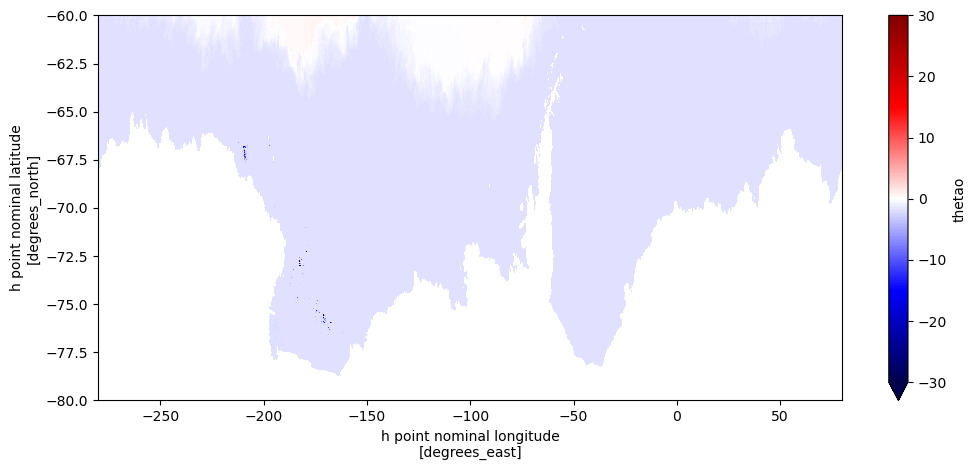

In [6]:
plt.figure(figsize = (12,5))
temp_vmin.plot(vmin=-30,vmax=30,cmap='seismic')
plt.ylim(-80,-60)

(-80.0, -60.0)

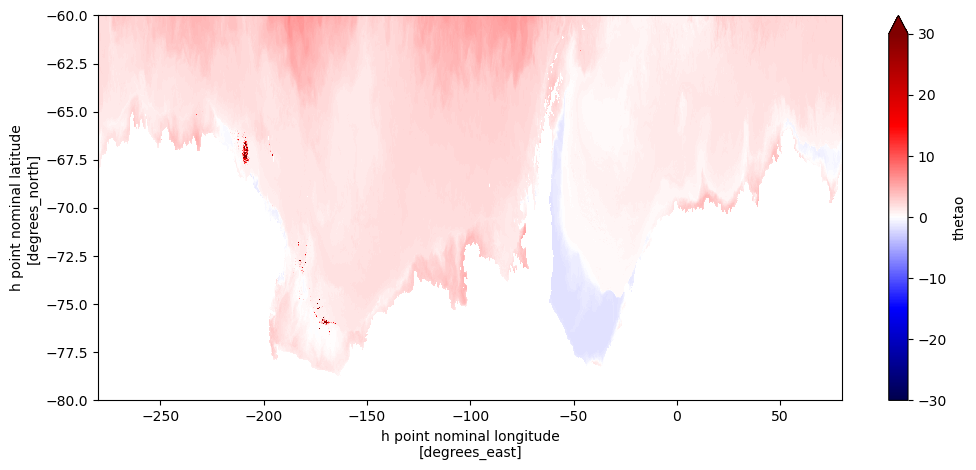

In [7]:
plt.figure(figsize = (12,5))
temp_vmax.plot(vmin=-30,vmax=30,cmap='seismic')
plt.ylim(-80,-60)

## Part 2, figuring out the layer thickness and volume of these weird cells

In [8]:
tarea = cc.querying.getvar('panant-005-zstar-ACCESSyr2','areacello',session,n=1)

In [9]:
drhot = volcello /tarea

In [10]:
#longitude slice where the spurious temperature happen
lon_slice = slice(-250,-150)
lat_slice = slice(-80,-60)

#cutting diagnostic data into the slices we want
temp_masked_sliced = temp_masked.sel(xh = lon_slice, yh= lat_slice)
drhot_sliced = drhot.sel(xh = lon_slice, yh= lat_slice)

In [14]:
arg_rhomin = temp_masked_sliced.where(temp_masked_sliced<-10).fillna(1e30).argmin('rho2_l').compute()
arg_rhomax  = temp_masked_sliced.where(temp_masked_sliced>10).fillna(-1e30).argmax('rho2_l').compute()

In [ ]:
drhot_mininrho = drhot_sliced.isel(rho2_l = arg_rhomin).compute()
drhot_maxinrho = drhot_sliced.isel(rho2_l = arg_rhomax).compute()

In [ ]:
drhot_mininrho